Some simple code for displaying some of the slices and their segmentation masks

In [1]:
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

In [12]:
from src.label_sessions.generate_mosaics import display_slice
from src.data import get_samples_df
from src.data import DicomDataset, VisualParams
from src.brain_transforms import get_spatial_transform_list, get_color_transform_list

In [3]:
data_path = Path('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/final.csv')

In [4]:
vis_params = VisualParams(display_method = 'stack2', 
                    norm_method = 'min-max', 
                    masked_norm = True,
                    percentile_norm   = .02)

data_samples_df, person_ids = get_samples_df(data_path, include_edges = False)
train_dataset = DicomDataset(data_samples_df, vis_params = vis_params, person_ids = person_ids, summarize_name = 'bleh bleh')


Full Dataset has 6970 samples
label
0    5781
1    1189
Name: count, dtype: Int64
bleh bleh
----------------
{'pos': 1189, 'neg': 5781, 'total': 6970}
----------------



/data/vision/polina/users/marcusbl/bin_class/src/data.py:209: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['label'] = df_new[label_col_name].astype('Int64')


In [5]:
idxs = [80, 30, 50, 99]

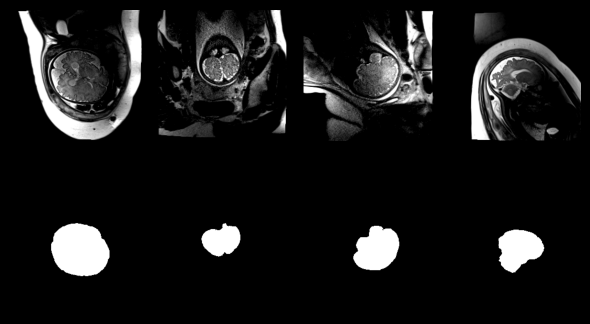

In [ ]:
fig, ax = plt.subplots(nrows = 2, ncols = 4, figsize = (6,4))
for i, idx in enumerate(idxs):
    img, mask = train_dataset[idx][0][0, :, :], train_dataset[idx][1]
    ax[0, i].imshow(img, cmap='grey', vmin=0, vmax = 1)
    ax[1, i].imshow(mask, cmap='grey', vmin=0, vmax = 1)

    ax[0, i].axis("off")
    ax[1, i].axis("off")

plt.tight_layout()
plt.savefig('segmentation.png')

In [20]:
def apply_aug(dataset: DicomDataset, method = ''):
    augmentation_list = []
    
    if 's' in method:
        print("Applying Spatital Augmentations")
        augmentation_list.extend(get_spatial_transform_list().copy())
    if 'c' in method:
        print("Applying Color Augmentations")
        augmentation_list.extend(get_color_transform_list().copy())

    dataset.set_aug(augmentation_list)

In [23]:
idxs = [80, 30, 50, 99]
aug_options = ['', 's', 'c']


here
[]
s
Applying Spatital Augmentations
here
[<src.brain_transforms.RandomFlip object at 0x7f59e92b5150>, <src.brain_transforms.RandomFlip object at 0x7f59c8168f90>, <src.brain_transforms.RandomAffineTransform object at 0x7f59e072ef10>]
c
Applying Color Augmentations
here
[<src.brain_transforms.RandomBrightness object at 0x7f59e0553290>, <src.brain_transforms.RandomContrast object at 0x7f59e04a1cd0>]


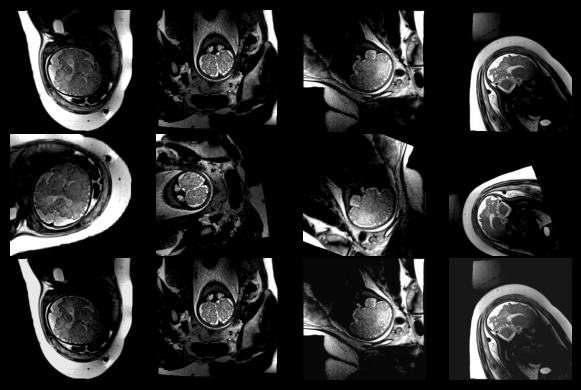

In [24]:
fig, ax = plt.subplots(nrows = len(aug_options), ncols = 4, figsize = (6,4))

for i, aug_method in enumerate(aug_options):
    print(aug_method)
    apply_aug(train_dataset, aug_method)
    print("here")
    print(train_dataset.augmentations)
    for j, idx in enumerate(idxs):
        img, mask = train_dataset[idx][0][0, :, :], train_dataset[idx][1]
        ax[i, j].imshow(img, cmap='grey', vmin=0, vmax = 1)

        ax[i, j].axis("off")

    plt.tight_layout()
